# Exploratory Data Analysis (EDA) — Iris Dataset

## What is EDA and Why Do It?

Before you train any model, you should **explore and understand your data**. This step is called Exploratory Data Analysis (EDA). Skipping it is one of the most common beginner mistakes.

EDA helps you answer critical questions:
- What does the data look like? How many samples, how many features?
- Are the classes balanced? (If 90% of samples are one class, the model might just always guess that class.)
- Which features look useful for telling the classes apart?
- Are there patterns, outliers, or problems you need to handle before training?

**How to use this notebook:** Run each cell in order (click a cell, then press `Shift+Enter`). Read the markdown explanations between code cells — they tell you what to look for in each visualization.

**After you finish this notebook**, run `python train.py` to train the model. The insights you gain here will help you understand why the model performs the way it does.

In [1]:
# --- IMPORTS ---
# pandas:       For loading data into a table (DataFrame) we can manipulate
# matplotlib:   For creating charts and plots
# seaborn:      For prettier, more informative statistical plots
# load_iris:    Loads the Iris dataset directly from scikit-learn (no file downloads)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the Iris dataset.
# This returns an object with .data (the measurements), .target (the species
# as integers 0/1/2), .feature_names, and .target_names.
iris = load_iris()

# Create a DataFrame — a table with labeled columns.
# This makes it much easier to inspect and visualize compared to raw arrays.
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Map the numeric target values (0, 1, 2) to their species names.
# This makes our plots show "setosa" instead of "0".
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# FIRST LOOK: Always start by viewing a few rows of your data.
# Ask yourself: Do the column names make sense? Do the values look reasonable?
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Dataset Overview

The Iris dataset contains **150 samples** of iris flowers from **3 species**:
- **Setosa** — tends to have smaller petals
- **Versicolor** — intermediate measurements
- **Virginica** — tends to have larger petals

Each sample has **4 measurements** (called *features* in ML):
| Feature | What it measures |
|---------|------------------|
| Sepal length | Length of the outer leaf-like part of the flower (cm) |
| Sepal width | Width of the sepal (cm) |
| Petal length | Length of the inner colored part of the flower (cm) |
| Petal width | Width of the petal (cm) |

The model's job is to learn: **given these 4 measurements, which species is it?**

In [2]:
# SUMMARY STATISTICS
# .describe() shows count, mean, std, min, max, and percentiles for each feature.
#
# WHAT TO LOOK FOR:
#   - Count: Are there missing values? (count < 150 would mean some are missing)
#   - Mean vs. Median (50%): Large differences suggest skewed distributions
#   - Min/Max: Any extreme outliers? Do the ranges make sense physically?
#   - Std (standard deviation): How spread out are the values?

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [3]:
# CLASS BALANCE CHECK
# This tells you how many samples belong to each species.
#
# WHY THIS MATTERS:
#   If one class has way more samples than others (e.g., 130 setosa vs. 10 each
#   for the others), the model might learn to just always guess the majority class.
#   That would give high accuracy but be practically useless.
#
#   Balanced classes (roughly equal counts) are ideal for beginners.
#   The Iris dataset has exactly 50 samples per species — perfectly balanced.

print("Samples per species:")
print(df["species"].value_counts())
print(f"\nTotal samples: {len(df)}")
print("\n-> Classes are perfectly balanced (50 each). No rebalancing needed.")

Samples per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Total samples: 150

-> Classes are perfectly balanced (50 each). No rebalancing needed.


## Feature Distributions

Histograms show how each feature's values are spread out, colored by species.

**What to look for:**
- **Separation:** If the colored bars for different species don't overlap, the feature is great for telling species apart. The model will love it.
- **Overlap:** Where species overlap in a feature, the model will need other features to help distinguish them.
- **Shape:** Are values spread evenly, or clustered in one spot? Weird shapes might indicate outliers or measurement issues.

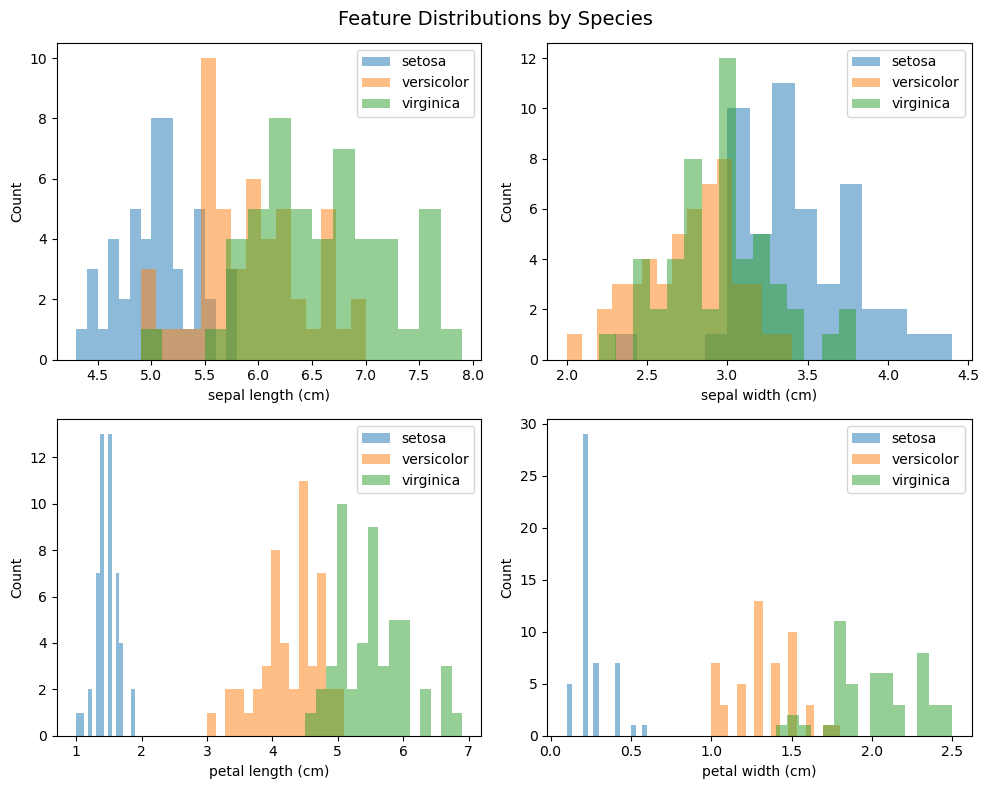

In [4]:
# Create a 2x2 grid of histograms — one per feature, colored by species.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Feature Distributions by Species", fontsize=14)

for ax, feature in zip(axes.ravel(), iris.feature_names):
    for species in iris.target_names:
        subset = df[df["species"] == species]
        ax.hist(subset[feature], bins=15, alpha=0.5, label=species)
        # alpha=0.5 makes bars semi-transparent so overlapping species are visible
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# OBSERVATIONS TO NOTE:
#   - Petal length and petal width show CLEAR separation between species
#   - Sepal measurements show much more overlap
#   - Setosa (blue) is clearly separated from the other two in petal features

## Pairwise Relationships

A **pairplot** shows every possible combination of two features plotted against each other, with points colored by species.

**What to look for:**
- **Distinct clusters:** If species form separate groups, the model can draw boundaries between them. This is what makes a classification problem "easy" vs. "hard."
- **Overlapping clusters:** Where species blend together, the model will struggle and make more mistakes.
- **Diagonal plots (KDE curves):** These show the distribution of each single feature by species. Sharp, non-overlapping curves = very discriminative feature.

This is one of the most informative EDA plots. Take a moment to study it.

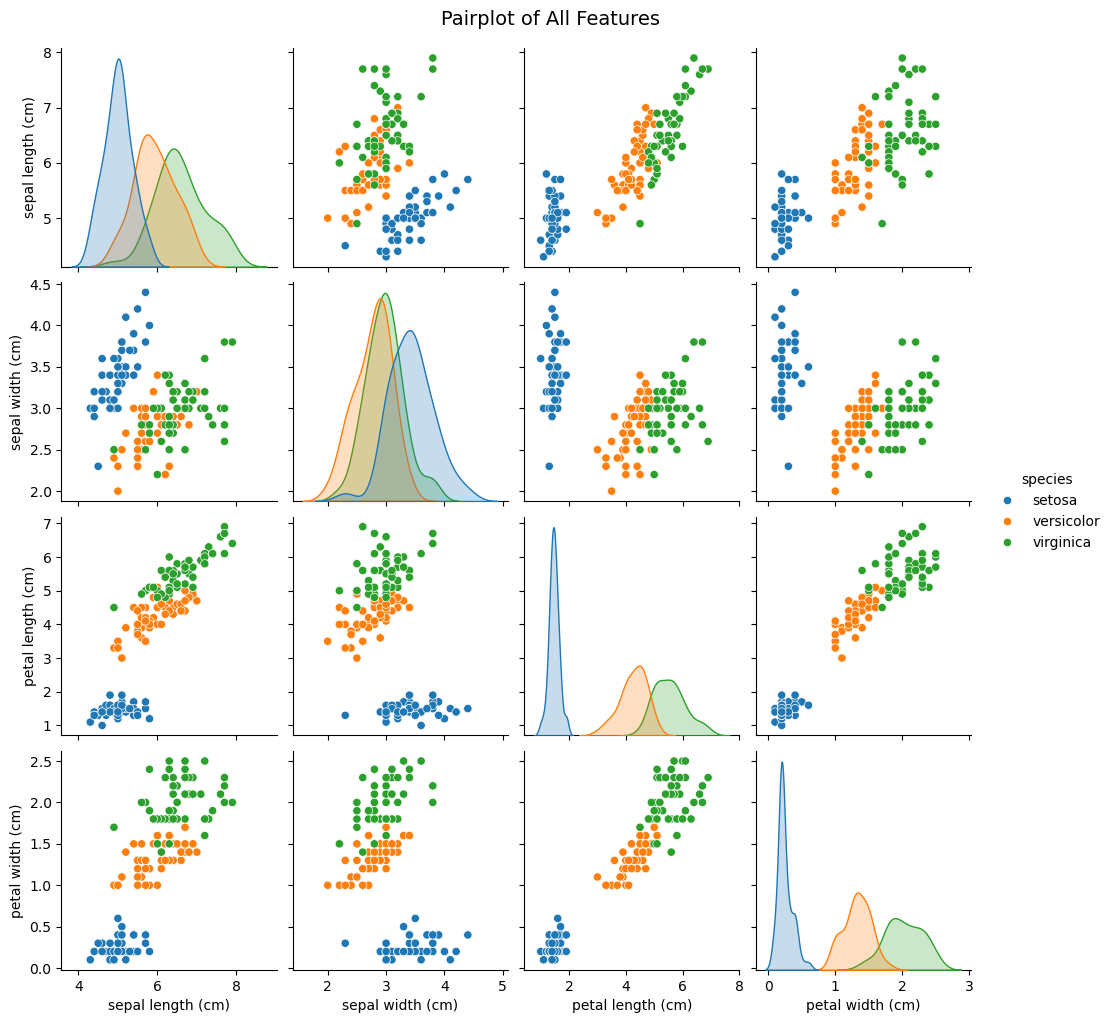

In [5]:
# Create the pairplot.
# hue="species" colors each point by its species.
# diag_kind="kde" shows smooth density curves on the diagonal instead of histograms.
#
# NOTE: This plot takes a moment to render because it creates 4x4 = 16 subplots.

sns.pairplot(df, hue="species", diag_kind="kde")
plt.suptitle("Pairplot of All Features", y=1.02, fontsize=14)
plt.show()

# OBSERVATIONS TO NOTE:
#   - Setosa (typically blue) is clearly separable in almost every subplot.
#     This is called being "linearly separable" — you could draw a straight
#     line to separate it from the other two species.
#   - Versicolor and virginica overlap in several feature combinations,
#     especially involving sepal measurements. The model will need to use
#     multiple features together to distinguish them.
#   - The petal length vs. petal width subplot shows the cleanest clustering.

## Correlation Heatmap

**Correlation** measures how strongly two features move together:
- **+1.0** = perfect positive correlation (when one increases, the other always increases)
- **-1.0** = perfect negative correlation (when one increases, the other always decreases)
- **0.0** = no relationship

**Why this matters for ML:**
- Highly correlated features carry *redundant* information. If petal length and petal width are 0.96 correlated, knowing one tells you almost everything the other would.
- In more advanced projects, you might drop one of a highly correlated pair to simplify the model. For now, just observe the relationships.

In [ ]:
# Compute correlations between all pairs of numeric features.
# We drop the "species" column because it's categorical, not numeric.

plt.figure(figsize=(8, 6))
sns.heatmap(
    df.drop("species", axis=1).corr(),  # .corr() computes pairwise correlations
    annot=True,   # Show the correlation values in each cell
    cmap="coolwarm",  # Blue = negative correlation, Red = positive correlation
    fmt=".2f",    # Show 2 decimal places
    square=True,  # Make cells square for readability
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# OBSERVATIONS TO NOTE:
#   - Petal length and petal width are highly correlated (~0.96).
#     They carry similar information — both measure petal size.
#   - Sepal length correlates moderately with petal measurements.
#   - Sepal width has weak or negative correlations with other features,
#     meaning it provides somewhat independent information.

## Box Plots by Species

**Box plots** show the distribution of a feature for each species side by side.

**How to read a box plot:**
- The **box** spans the interquartile range (IQR) — the middle 50% of values
- The **line inside the box** is the median (middle value)
- The **whiskers** extend to the most extreme data points within 1.5x the IQR
- **Dots** beyond the whiskers are outliers

**What to look for:**
- If boxes for different species **don't overlap vertically**, the feature strongly separates them.
- If boxes **overlap heavily**, the feature alone isn't enough to tell species apart.

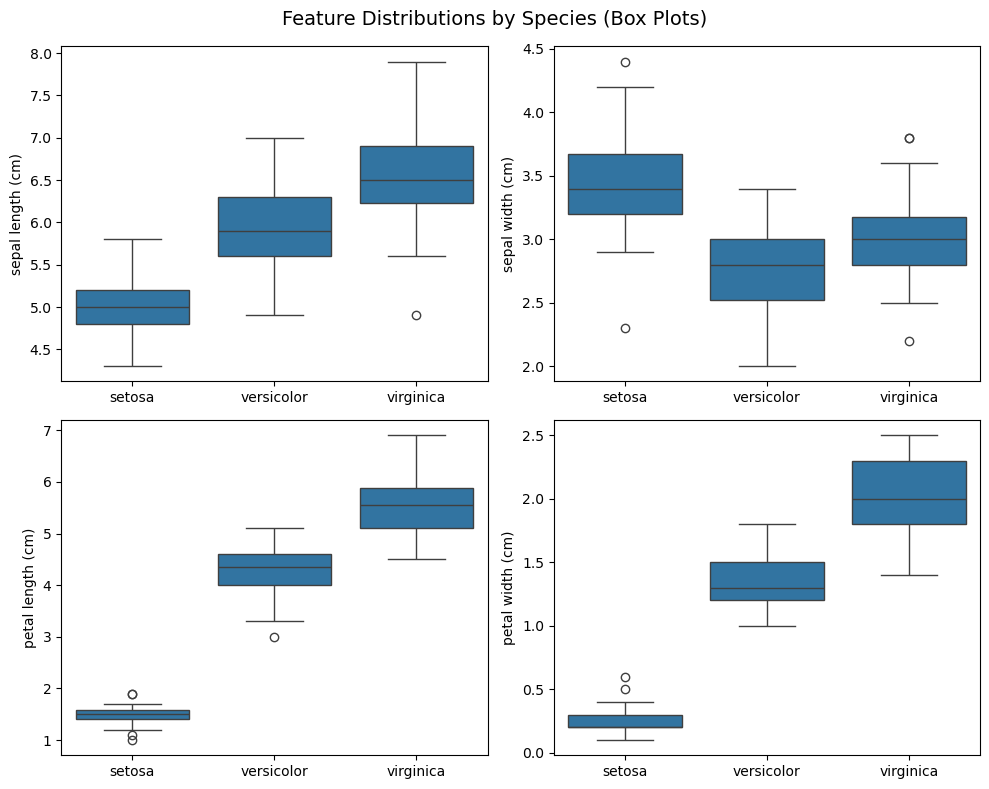

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Feature Distributions by Species (Box Plots)", fontsize=14)

for ax, feature in zip(axes.ravel(), iris.feature_names):
    sns.boxplot(x="species", y=feature, data=df, ax=ax)
    ax.set_xlabel("")  # Remove x-label to reduce clutter (species names are enough)

plt.tight_layout()
plt.show()

# OBSERVATIONS TO NOTE:
#   - Petal length: setosa boxes are completely below versicolor and virginica.
#     This feature alone can separate setosa from the rest.
#   - Sepal width: there's substantial overlap between all three species.
#     This feature is less useful on its own.
#   - Versicolor and virginica overlap in sepal measurements but are more
#     separable in petal measurements.

## Key Takeaways

Here's what this EDA revealed — and why it matters for training:

1. **Setosa is easy to classify.** It forms a distinct cluster in nearly every feature combination, especially petal measurements. The model will get these right almost every time.

2. **Petal length and petal width are the most useful features.** They show the clearest separation between all three species. Expect the model's feature importance scores to rank these highest.

3. **Versicolor and virginica are harder to separate.** They overlap in sepal measurements and partially overlap in petal measurements. If the model makes mistakes, it will most likely confuse these two species.

4. **Petal length and petal width are highly correlated (0.96).** They carry similar information. In a more advanced project, you might consider dropping one to simplify the model.

5. **The dataset is clean and balanced.** No missing values, no extreme outliers, and exactly 50 samples per species. This means we can train without worrying about data cleaning or class imbalance — luxuries you won't always have in real-world projects.

---

**Next step:** Run `python train.py` to train a Random Forest classifier on this data. As you read the model's evaluation output, see if the results match what you predicted from this EDA:
- Does the model achieve high accuracy? (You'd expect yes, given the clear clusters.)
- Which features does the model consider most important? (Should be petal features.)
- If there are errors in the confusion matrix, which species are confused? (Likely versicolor/virginica.)